In [2]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm

from obspy import Stream
from matplotlib.colors import LogNorm

import pandas as pd

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
#from new_functions import *
from processing_routines import *
from plotting_routines import *

5.7


In [37]:

Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.

event_name ='Nice 2025'
event_name ='Rochemaure'
event_name ='Corse 2011'
event_name ='Croatia 2023'

if event_name == 'Nice 2025':
    start = UTCDateTime("2025-03-18T17:40:00")
    end = UTCDateTime("2025-03-18T17:50:00")

if event_name == 'Rochemaure' :
    start = UTCDateTime("2019-11-11 10:50:46 ") #magnitude 4.9
    end = UTCDateTime("2019-11-11 10:55:46 ")



if event_name == 'Corse 2011':
    start = UTCDateTime("2011-07-07 19:15:00") #magnitude 5.2
    end = UTCDateTime("2011-07-07 19:35:00 ")




if event_name == 'Croatia 2023':
    start = UTCDateTime("2023-02-16 09:40:45") #magnitude 4.8
    end = UTCDateTime("2023-02-16 09:55:45")


minlat = 37
maxlat = 50.0
minlon = -5
maxlon = 17
minmag = 3.5


events_list = Client("EMSC").get_events(
    minlatitude=minlat,
    maxlatitude=maxlat,
    minlongitude=minlon,
    maxlongitude=maxlon,
    minmagnitude=minmag,
    starttime=start,
    endtime=end
)
print("\nFound %s event(s) from EMSC Data Center:\n" % len(events_list))
print(events_list.__str__(print_all=True))



eqo = events_list[0].origins[0]
eq_start = eqo.time
eq_mag = events_list[0].magnitudes[0].mag
print(type(eq_start))
t_duration=500. #length of window to request
eq_end = eq_start + t_duration
eq_lat=eqo.latitude
print((eq_end))
eq_lon=eqo.longitude
eq_epi=(eq_lat,eq_lon)


degmin=1.9
degmax=10.
start = eq_start -25
end = eq_end
datacenters=['RESIF','ODC','ETH','INGV','GEOFON', 'IRIS', 'ICGC','LMU','BGR']
st_all, stations_all, plot = big_downloader2(datacenters,start,end,eq_lon,eq_lat,degmin,degmax,directory='/home/schreinl/Stage/Data1/',plot=True)
plot

5.7

Found 1 event(s) from EMSC Data Center:

1 Event(s) in Catalog:
2023-02-16T09:47:46.200000Z | +44.970,  +14.750 | 4.8  mb | manual
<class 'obspy.core.utcdatetime.UTCDateTime'>
2023-02-16T09:56:06.200000Z
Earthquake at 2023-02-16T09:47:46.200000Z with magnitude 4.8


Processing stations of RESIF:   0%|          | 0/198 [00:00<?, ?it/s]/home/schreinl/miniconda3/envs/seislib/lib/python3.9/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
Processing stations of ODC:   7%|▋         | 11/167 [00:00<00:01, 85.89it/s]/home/schreinl/miniconda3/envs/seislib/lib/python3.9/site-packages/obspy/io/mseed/core.py:773: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
Processing stations of ODC:  48%|████▊     | 80/167 [00:22<01:29,  1.03s/it] WARNING (norm_resp): computed and reported sensitivities differ by more than 5 percent. 
	 Execution continuing.
Processing stations of ETH:   0%|          | 0/78 [00:00<?, ?it/s]/home/schreinl/miniconda3/envs/seislib/lib/python3.9/site-pac

Plotting record section...


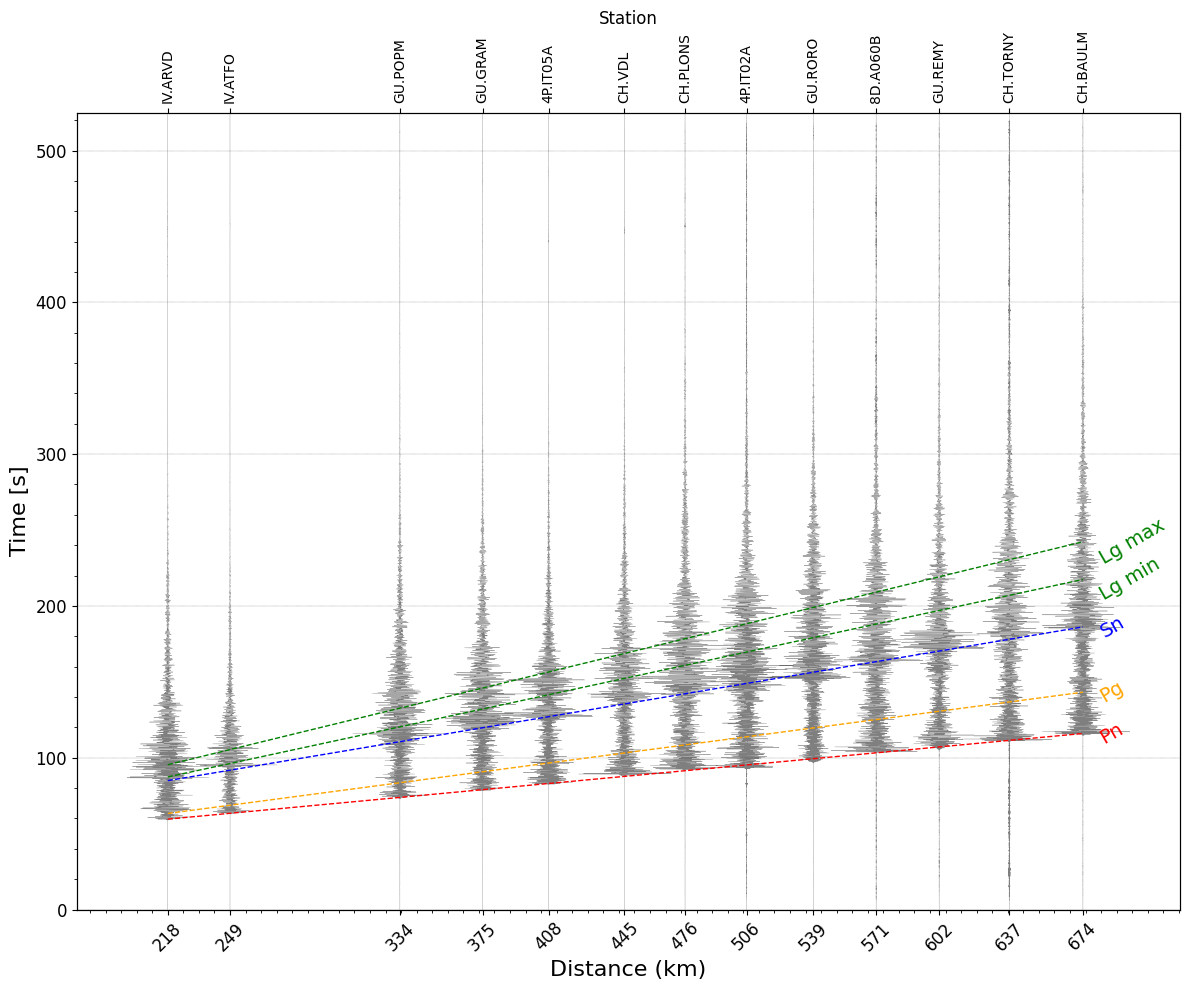

In [51]:
def select_spaced_stations(stations, min_spacing_km=30, max_stations=30):
    """
    Select up to `max_stations` spaced by at least `min_spacing_km` km.
    """
    selected = []
    last_dist = -np.inf
    for station in sorted(stations, key=lambda x: float(x[5])):  # Sort by distance
        dist_km = float(station[5]) / 1000.
        if dist_km - last_dist >= min_spacing_km:
            selected.append(station)
            last_dist = dist_km
        if len(selected) >= max_stations:
            break
    return selected


def plot_record_section(
    st, stations, eq_lat, eq_lon, eq_start, size=(1200, 1000), show=True, outfile=None,
    tracehodo=True, v_Lg_min=3.1, v_Lg_max=3.5, v_Pg=6., tmincoda=300, tmaxcoda=320
):
    print("Plotting record section...")
    if not st or not stations:
        print("Station or stream empty.")
        return

    st2 = Stream()
    station_array = np.array(stations)

    # Compute distances and phase arrival times
    dist_km = station_array[:, 5].astype(float) / 1000.
    t_Pn = station_array[:, 7].astype(float)
    t_Sn = station_array[:, 8].astype(float)
    t_Pg = station_array[:, 9].astype(float)
    idx_sorted = np.argsort(dist_km)
    dist_sorted = dist_km[idx_sorted]
    t_Pn_sorted = t_Pn[idx_sorted]
    t_Sn_sorted = t_Sn[idx_sorted]
    t_Pg_sorted = t_Pg[idx_sorted]

    # Lg arrival windows
    t_Lg_min = dist_sorted / v_Lg_max + 25
    t_Lg_max = dist_sorted / v_Lg_min + 25

    # Build new stream with distance and coordinates
    for tr in st:
        for net, sta, lat, lon, elev, dist, az, t_Pn, t_Sn, t_Pg in stations:
            if tr.stats.network == net and tr.stats.station == sta:
                tr.stats.coordinates = {"latitude": lat, "longitude": lon}
                tr.stats.distance = dist
                st2.append(tr)

    if len(st2) < 2:
        print("Cannot build plot section with less than two traces.")
        return

    # Trim and plot
    st2.trim(starttime=min(tr.stats.starttime for tr in st2), pad=True, fill_value=0)
    fig = plt.figure(figsize=(size[0] / 100, size[1] / 100))
    st2.plot(type="section", linewidth=0.25, grid_linewidth=0.25, fig=fig, norm_method='trace')
    ax = fig.axes[0]

    # Axis labels
    ax.set_xlabel("Distance (km)", fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.tick_params(axis='both', labelsize=12)

    # Sorted distance and station names
    station_names = [f"{station_array[i][0]}.{station_array[i][1]}" for i in idx_sorted]
    ax.set_xticks(dist_sorted)
    ax.set_xticklabels([f"{d:.0f}" for d in dist_sorted], rotation=45, fontsize=12)
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(dist_sorted)
    ax_top.set_xticklabels(station_names, rotation=90, fontsize=10, va='bottom')
    ax_top.set_xlabel("Station", fontsize=12)
    ax_top.xaxis.set_label_position('top')
    ax_top.xaxis.set_ticks_position('top')

    if tracehodo:
        crop_end = 1
        right_limit = dist_sorted[-1] * crop_end

        def crop_line(x, y):
            mask = x <= right_limit
            return x[mask], y[mask]

        lines = [
            (dist_sorted, t_Pn_sorted, 'r', 'Pn'),
            (dist_sorted, t_Sn_sorted, 'b', 'Sn'),
            (dist_sorted, t_Pg_sorted, 'orange', 'Pg'),
            (dist_sorted, t_Lg_min, 'g', 'Lg min'),
            (dist_sorted, t_Lg_max, 'g', 'Lg max'),
        ]

        for x, y, color, label in lines:
            x_crop, y_crop = crop_line(x, y)
            ax.plot(x_crop, y_crop, linestyle='--', color=color, linewidth=1)
            ax.text(x_crop[-1] + 7, y_crop[-1], label, color=color, va='center', fontsize=14, rotation=30)

        st_Lg = Stream()
        for tr in st2:
            dist = tr.stats.distance / 1000.
            t_Lg_min_tr = dist / v_Lg_max
            t_Lg_max_tr = dist / v_Lg_min
            st_Lg.append(tr.copy().trim(starttime=eq_start + t_Lg_min_tr, endtime=eq_start + t_Lg_max_tr))
    else:
        st_Lg = None

    fig.tight_layout()
    if outfile:
        plt.savefig(outfile)
    elif show:
        plt.show()
    return fig, st_Lg


selected_stations = []
stationis = stations_all[200:300]
last_dist = -1e6
for row in sorted(stationis, key=lambda x: x[5]):
    dist = float(row[5]) / 1000.
    if dist - last_dist >= 30:
        selected_stations.append(row)
        last_dist = dist
    if len(selected_stations) == 25:
        break


st_plot_filt_all = st_all.copy()
st_plot_filt_all.filter("bandpass", freqmin=1, freqmax=7)
bad_stations = {'AJAC', 'CAMF', 'PYLO', 'MORSI','STR', 'CFNM', 'LOUF', 'CAMF'}
st_plot_filt_all = obspy.Stream(tr for tr in st_plot_filt_all if tr.stats.station not in bad_stations)

station_names = {s[1] for s in selected_stations}
station_names.add('CLUD')
st_filtered = obspy.Stream(tr for tr in st_all if tr.stats.station in station_names)

fmin, fmax = 1, 7
st_filtered.filter("bandpass", freqmin=fmin, freqmax=fmax)

plot, st_Lg0 = plot_record_section(
    st_filtered, selected_stations, eq_lat, eq_lon, start,
    tracehodo=True, v_Lg_min=vLg_min, v_Lg_max=vLg_max, v_Pg=vPg
)


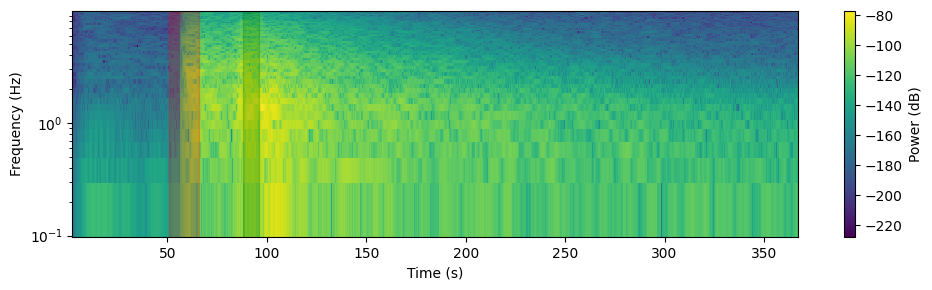

In [50]:
from scipy.signal import spectrogram




st_plot_filt_all=st_all.copy()
fmin=0.01
fmax=9.9
st_plot_filt_all.filter("bandpass", freqmin=fmin, freqmax=fmax)



stationname = 'CLUD'
trace = next((tr for tr in st_plot_filt_all if tr.stats.station == stationname), None)
if trace is None:
    raise ValueError(f"Station {stationname} not found in the stream.")

station = trace.stats.station
distance = next(row[5] for row in stations_all if row[1] == station) / 1000
t_Lg_min = distance / 3.5  +25
t_Lg_max = distance / 3.1 +25
nfft = 512
overlap = 0.9
sampling_rate = trace.stats.sampling_rate

desired_duration = tmaxCoda + 50 
desired_samples = int(desired_duration * sampling_rate)
if len(trace.data) < desired_samples:
    pad_length = desired_samples - len(trace.data)
    data_cut = np.pad(trace.data, (0, pad_length), mode='constant')
else:
    data_cut = trace.data[:desired_samples]

f, t, Sxx = spectrogram(
    data_cut,
    fs=sampling_rate,
    nperseg=nfft,
    noverlap=int(nfft * overlap),
    nfft=nfft
)
freq_mask = (f >= fmin) & (f <= fmax)
filtered_frequencies = f[freq_mask]
filtered_spectrum = Sxx[freq_mask, :]
#filtered_spectrum = filtered_spectrum - np.min(filtered_spectrum)
#filtered_spectrum = filtered_spectrum / np.max(filtered_spectrum)


plt.figure(figsize=(10, 3))
plt.pcolormesh(t, filtered_frequencies, 10 * np.log10(filtered_spectrum ), shading='auto', cmap='viridis')

plt.colorbar(label='Power (dB)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
#plt.title(f"Spectrogram of Station {trace.stats.station} ({fmin}-{fmax} Hz)")
plt.yscale('log')

for station_data in stations_all:
    if station_data[1] == station:  
        t_Pn = station_data[7] - 4
        t_Sn = station_data[8]
        t_Pg = station_data[9]
        # Lg window box
        plt.fill_betweenx(
            filtered_frequencies,
            t_Lg_min,
            t_Lg_max,
            color='g',
            alpha=0.0,
            label='Lg Window'
        )
        # Pn window box
        plt.fill_betweenx(
            filtered_frequencies,
            t_Pn - 5,
            t_Pn + 10,
            color='r',
            alpha=0.0,
            label='Pn Window'
        )
        # Extend fill to zero frequency for both windows
        plt.fill_betweenx(
            np.concatenate(([0], filtered_frequencies)),
            t_Lg_min,
            t_Lg_max,
            color='g',
            alpha=0.15
        )
        plt.fill_betweenx(
            np.concatenate(([0], filtered_frequencies)),
            t_Pn - 5,
            t_Pn + 10,
            color='r',
            alpha=0.12
        )

#plt.axvline(tminCoda, color='purple', linestyle='--', label='Coda Start')
#plt.axvline(tmaxCoda, color='purple', linestyle='--', label='Coda End')

#plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


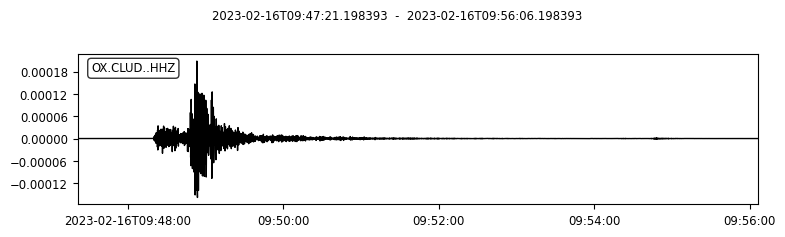

87.90525069268557
96.02205723367724


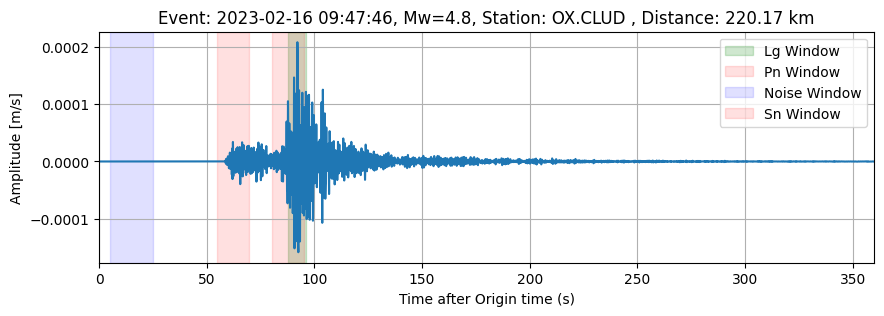

In [54]:
Bouf = next((tr for tr in st_plot_filt_all if tr.stats.station == stationname), None)
if Bouf is None:
    raise ValueError(f"Station {stationname} not found in st_plot_filt_all.")
net = Bouf.stats.network
distance = next(row[5] for row in stations_all if row[1] == stationname)
dist = distance / 1000
Pnt = next(row[7] for row in stations_all if row[1] == stationname)
Snt = next(row[8] for row in stations_all if row[1] == stationname)
Bouf.plot()

t1 = (distance/1000)/vLg_max +25
t2 = (distance/1000)/vLg_min + 25
print(t1)
print(t2)

timeseries = Bouf.data
dt = Bouf.stats.delta
t = np.arange(0, len(timeseries)) * dt

plt.figure(figsize=(10, 3))
plt.plot(t, timeseries)
plt.xlabel('Time after Origin time (s)')
plt.ylabel('Amplitude [m/s]')
plt.title(f'Event: {eq_start.strftime("%Y-%m-%d %H:%M:%S")}, Mw={eq_mag}, Station: {net}.{stationname} , Distance: {dist:.2f} km')

# Highlight Lg window
plt.axvspan(t1, t2, color='g', alpha=0.19, label='Lg Window')
# Highlight Pn window
plt.axvspan(Pnt - 5, Pnt + 10, color='r', alpha=0.12, label='Pn Window')
plt.axvspan(5, 25, color='b', alpha=0.12, label='Noise Window')
# Highlight Sn window
plt.axvspan(Snt - 5, Snt + 10, color='r', alpha=0.12, label='Sn Window')


plt.xlim(0, 360)
plt.legend()
plt.grid()
plt.show()


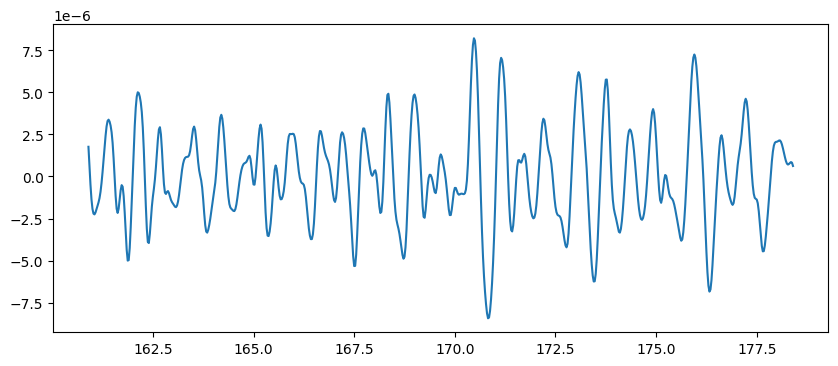

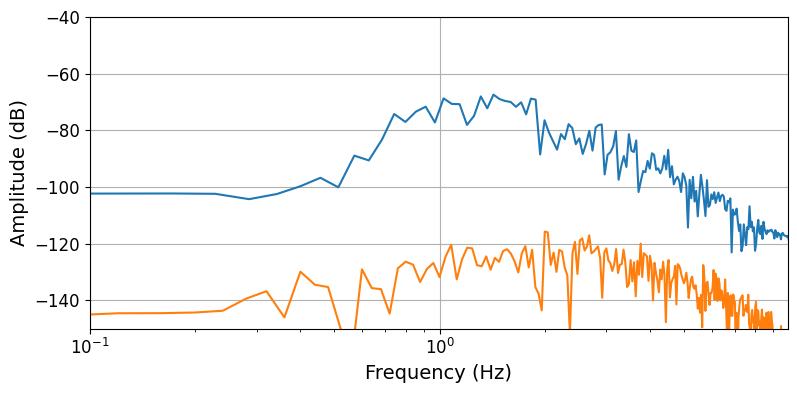

In [42]:
idx_start = np.searchsorted(t, t_Lg_min)
idx_end = np.searchsorted(t, t_Lg_max)
segment = Bouf.data[idx_start:idx_end]
idxnoise = np.searchsorted(t, 0)
idxnoise_end = np.searchsorted(t, 25)
segment_noise = Bouf.data[idxnoise:idxnoise_end]
segment_noise = segment_noise - np.mean(segment_noise)
segment = segment - np.mean(segment)


plt.figure(figsize=(10, 4))
plt.plot(t[idx_start:idx_end], segment, label='Segment')
plt.show(   )
N = len(segment)
dt = trace.stats.delta
freqs = np.fft.rfftfreq(N, d=dt)
fft_vals = np.fft.rfft(segment)
amplitude = np.abs(fft_vals)

Nnoise = len(segment_noise)
dt = trace.stats.delta
freqs_noise = np.fft.rfftfreq(Nnoise, d=dt)
fft_vals_noise = np.fft.rfft(segment_noise)
amplitude_noise = np.abs(fft_vals_noise)

plt.figure(figsize=(8, 4))
plt.semilogx(freqs, 20 * np.log10(amplitude), label='FFT Amplitude Spectrum')
plt.semilogx(freqs_noise, 20 * np.log10(amplitude_noise), label='FFT Amplitude Spectrum Noise')
plt.xlim(fmin, fmax)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylim(-150, -40)
plt.xlim(0.1,fmax)
plt.ylabel('Amplitude (dB)', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

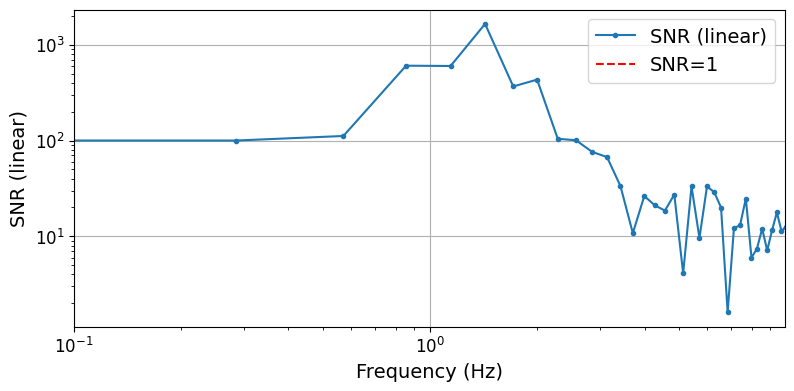

In [43]:
min_len = min(len(amplitude), len(amplitude_noise))
freqs_common = freqs[:min_len][::5]
amplitude_signal = amplitude[:min_len][::5]
amplitude_noise = amplitude_noise[:min_len][::5]

amplitude_noise[amplitude_noise == 0] = 1e-20

snr = amplitude_signal / amplitude_noise
snr_db = 20 * np.log10(snr)

plt.figure(figsize=(8, 4))
plt.loglog(freqs_common, snr, label='SNR (linear)', marker='o', markersize=3)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.hlines(1, freqs_common[0], freqs_common[-1], color='r', linestyle='--', label='SNR=1')
plt.ylabel('SNR (linear)', fontsize=14)
plt.xlim(0.1, fmax)
plt.grid(True)
plt.tight_layout()
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


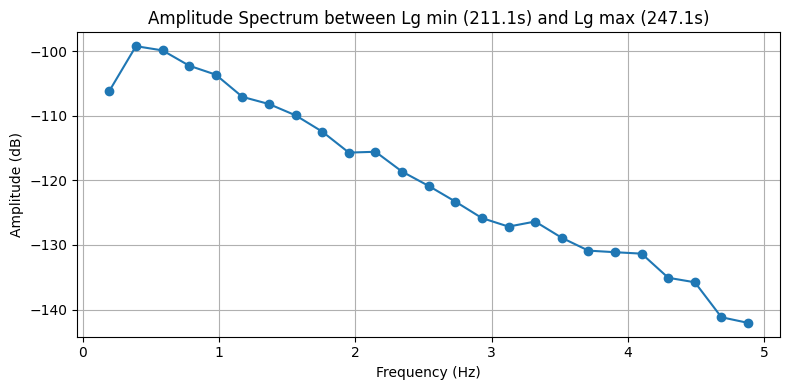

In [ ]:
idx_min = np.searchsorted(t, t_Lg_min)
idx_max = np.searchsorted(t, t_Lg_max)

spectrum_lg = np.mean(filtered_spectrum[:, idx_min:idx_max], axis=1)

plt.figure(figsize=(8, 4))
plt.plot(filtered_frequencies, 10 * np.log10(spectrum_lg), marker='o')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')
plt.title(f'Amplitude Spectrum between Lg min ({t_Lg_min:.1f}s) and Lg max ({t_Lg_max:.1f}s)')
plt.grid(True)
plt.tight_layout()
plt.show()

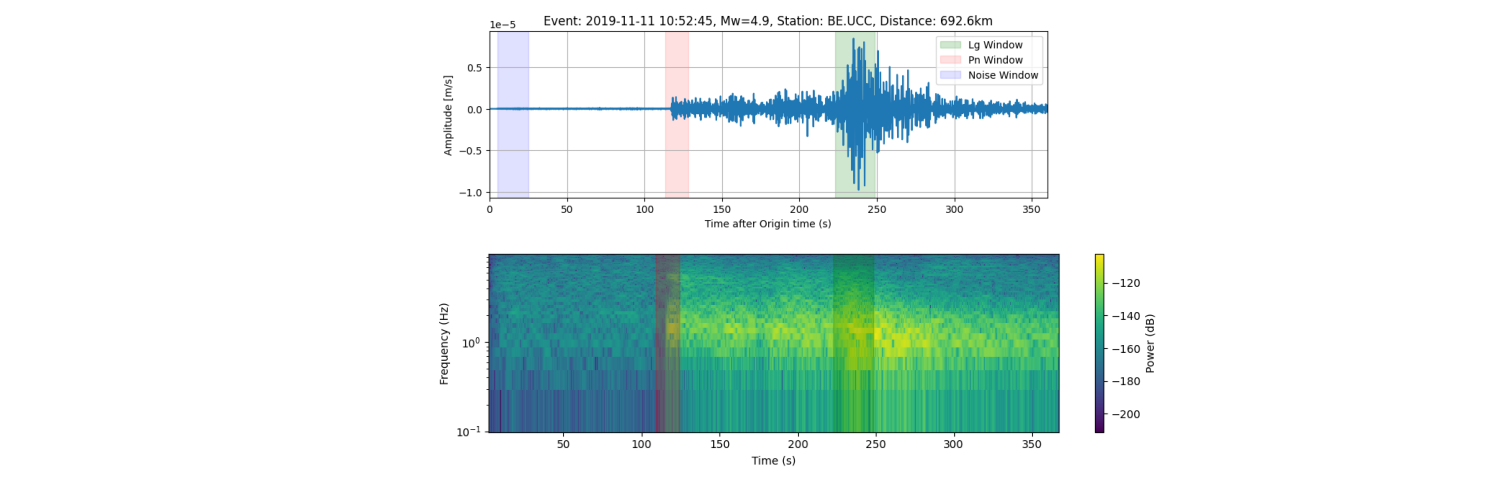

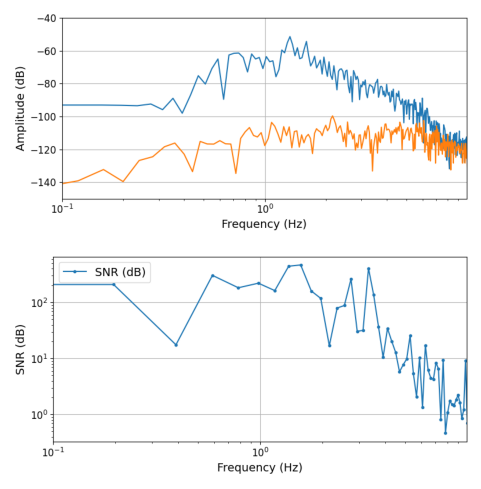

In [183]:
from PIL import Image
from matplotlib.transforms import Affine2D

import matplotlib.pyplot as plt

fig2_path = '../Figures/spectrum_SNR_UCC_Rochemaure.png'
fig3_path = '../Figures/spectrum_UCC_Rochemaure.png'
fig1_path = '../Figures/trace_UCC_Rochemaure.png'
fig4_path = '../Figures/spectro_UCC_Rochemaure.png'

img1 = Image.open(fig1_path)
img2 = Image.open(fig2_path)
img3 = Image.open(fig3_path)
img4 = Image.open(fig4_path)

#img2 = img2.resize(img1.size)
#img4 = img4.resize(img3.size)
fig, axes = plt.subplots(2, 1, figsize=(15, 5))
axes[0].imshow(img1)
axes[0].axis('off')
# Shift the lower image to the right by adding left padding
#offset = Affine2D().translate(60, 0) + axes[1].transData
axes[1].imshow(img4, transform=offset)
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].imshow(img3)
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].axis('off')
plt.tight_layout()
plt.show()


In [44]:
#stations_with_amps: 
#net (0), sta (1), lat (2), lon (3), elev (4) , dist(5), az(6), 
# t_Pn (7), t_Sn (8), t_Pg(9), A_Pn (10), A_Sn (11), A_Lg(12), A_Coda(13), A_Noise(14), A_pg(15)

stations_with_amps=calc_amps(stations_all, 
st_plot_filt_all, Dtmin_Pn, Dtmax_Pn, Dtmin_Sn, Dtmax_Sn, vLg_min,vLg_max,vPg_min, vPg_max, tminCoda, tmaxCoda, Dtmin_Noise, Dtmax_Noise,eq_start)



def select_ratio(wavecode, stations_with_amps):
    '''
    this only works when the stations_with amps file is in this format:
    net (0), sta (1), lat (2), lon (3), elev (4) , dist(5), az(6), 
    t_Pn (7), t_Sn (8), t_Pg(9), A_Pn (10), A_Sn (11), A_Lg(12), A_Coda(13), A_Noise(14), A_pg(15)

    '''
    distDraw=stations_with_amps[:,5].astype(float)/1000.
    azDraw=stations_with_amps[:,6].astype(float) 

    if wavecode == 'Pn' :
        Amp_Draw=stations_with_amps[:,10].astype(float)
    elif wavecode == 'Sn' :
        Amp_Draw=stations_with_amps[:,11].astype(float)
    elif wavecode == 'Lg' :
        Amp_Draw=stations_with_amps[:,12].astype(float)  
    elif wavecode == 'Coda' :
        Amp_Draw=stations_with_amps[:,13].astype(float)    
    elif wavecode == 'Noise' :
        Amp_Draw=stations_with_amps[:,14].astype(float) 
    elif wavecode == 'Pg' :
        Amp_Draw=stations_with_amps[:,15].astype(float)
    elif wavecode== 'Pg_Coda':
        Amp_Draw=np.divide(stations_with_amps[:,15].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Pn' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,10].astype(float))
    elif wavecode == 'Lg_Pg' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,15].astype(float))
    elif wavecode == 'Lg_Sn' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,11].astype(float))
    elif wavecode == 'Pn_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,10].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Sn_Coda' :
        Amp_Draw=np.divide(stations_with_amps[:,11].astype(float),stations_with_amps[:,13].astype(float))
    elif wavecode == 'Lg_Noise' :
        Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,14].astype(float))
    elif wavecode == 'Coda_Noise' :
        Amp_Draw=np.divide(stations_with_amps[:,13].astype(float),stations_with_amps[:,14].astype(float))
    else:
        Amp_Draw = np.zeros(stations_with_amps.shape[0])
        print('wavecode not recognized')
    Amp_Draw[np.isnan(Amp_Draw)] = 0    
    Amp_Draw[np.isinf(Amp_Draw)] = 0
    return Amp_Draw



wavecode='Lg_Coda'

distDraw=stations_with_amps[:,5].astype(float)/1000.
azDraw=stations_with_amps[:,6].astype(float) 

if wavecode == 'Pn' :
    Amp_Draw=stations_with_amps[:,10].astype(float)
elif wavecode == 'Sn' :
    Amp_Draw=stations_with_amps[:,11].astype(float)
elif wavecode == 'Lg' :
    Amp_Draw=stations_with_amps[:,12].astype(float)  
elif wavecode == 'Coda' :
    Amp_Draw=stations_with_amps[:,13].astype(float)    
elif wavecode == 'Noise' :
    Amp_Draw=stations_with_amps[:,14].astype(float) 
elif wavecode == 'Pg' :
    Amp_Draw=stations_with_amps[:,15].astype(float)
elif wavecode == 'Lg_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Lg_Pn' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,10].astype(float))
elif wavecode == 'Lg_Pg' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,15].astype(float))
elif wavecode == 'Lg_Sn' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,11].astype(float))
elif wavecode == 'Pn_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,10].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Sn_Coda' :
    Amp_Draw=np.divide(stations_with_amps[:,11].astype(float),stations_with_amps[:,13].astype(float))
elif wavecode == 'Lg_Noise' :
    Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,14].astype(float))
elif wavecode == 'Coda_Noise' :
    Amp_Draw=np.divide(stations_with_amps[:,13].astype(float),stations_with_amps[:,14].astype(float))
else:
    Amp_Draw = np.zeros(stations_with_amps.shape[0])
    print('wavecode not recognized')
Amp_Draw[np.isnan(Amp_Draw)] = 0    
Amp_Draw[np.isinf(Amp_Draw)] = 0

print(Amp_Draw.shape)
print(stations_with_amps.shape)


if stations_with_amps[1, 1] == 'PLONS':
    Bouf = stations_with_amps[1]
    # Bouf.plot()  # Uncomment if Bouf is a plottable object


(749,)
(749, 16)


/tmp/ipykernel_12551/2213470490.py:77: RuntimeWarning: invalid value encountered in divide
  Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))


In [45]:
wavecode='Lg_Coda'

Amp_Draw = select_ratio(wavecode, stations_with_amps)
if Amp_Draw is not None:
    print()
    plot =plot_stations_amps(stations_with_amps, 1, 0.7, Amp_Draw, origin=[eq_lat,eq_lon], zoom=5, forcescale=False)
plot

/tmp/ipykernel_12551/2213470490.py:35: RuntimeWarning: invalid value encountered in divide
  Amp_Draw=np.divide(stations_with_amps[:,12].astype(float),stations_with_amps[:,13].astype(float))
